# Revolut GP L90D: root cause analysis and recommendations

**Objective:** Identify what is driving the decline in GP L90D and recommend interventions to achieve a £4M improvement within 6-12 months.

**Dataset:** 196,187 user-level P&L records covering April 24 to July 23, 2024. Each row represents a user's gross profit contribution on a given date, broken down by P&L account hierarchy (levels 1-4).

**Key note:** The `amount_gbp` column is denominated in £1,000s as stated in the documentation. All values below are converted to actual GBP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Chart styling
BG = '#0A0A0A'
BLUE = '#0075EB'
RED = '#EF4444'
GREEN = '#10B981'
TEXT = '#FFFFFF'
MUTED = '#9A9A9A'
BORDER = '#2A2A2A'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': BORDER, 'axes.grid': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.alpha': 0.1, 'grid.color': '#1F1F1F',
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.titlecolor': TEXT, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TEXT, 'figure.dpi': 120,
    'savefig.facecolor': BG,
})

def fmt(val):
    if abs(val) >= 1_000_000: return f'£{val/1_000_000:.2f}M'
    if abs(val) >= 1_000: return f'£{val/1_000:.0f}K'
    return f'£{val:.0f}'

## 1. Load and inspect the data

In [2]:
df = pd.read_csv('dataset.csv')

# Drop unnamed index column
if df.columns[0] == '' or df.columns[0].startswith('Unnamed'):
    df = df.drop(columns=[df.columns[0]])

# Convert amount from £1,000s to actual GBP
df['amount_gbp'] = pd.to_numeric(df['amount_gbp'], errors='coerce') * 1000
df['pnl_date'] = pd.to_datetime(df['pnl_date'])
df['onboarded_date'] = pd.to_datetime(df['onboarded_date'], errors='coerce')

print(f'Rows: {len(df):,}')
print(f'Unique users: {df["user_id"].nunique():,}')
print(f'Date range: {df["pnl_date"].min().date()} to {df["pnl_date"].max().date()}')
print(f'Total GP (all months): {fmt(df["amount_gbp"].sum())}')
print(f'\nColumns: {list(df.columns)}')
df.head(3)

Rows: 196,187
Unique users: 191,412
Date range: 2024-04-24 to 2024-07-23
Total GP (all months): £8.34M

Columns: ['user_id', 'pnl_date', 'user_city', 'user_country', 'account_level_1', 'account_level_2', 'account_level_3', 'account_level_4', 'amount_gbp', 'user_type', 'age_group', 'onboarded_date', 'user_state', 'user_plan', 'is_nap', 'pnl_month']


,user_id,pnl_date,user_city,user_country,account_level_1,account_level_2,account_level_3,account_level_4,amount_gbp,user_type,age_group,onboarded_date,user_state,user_plan,is_nap,pnl_month
0,e4457c08,2024-06-02,Banbridge,United Kingdom,Revolut Retail,Card Payments,ATM,Partner: Fire,-81.654990,PERSONAL,65-74,2018-03-22 09:11:32.417000+00:00,Active,PREMIUM,Napped,2024-06
1,c4373067,2024-07-11,NaN,Ireland,Revolut Retail,Card Payments,Interchange Fees,Partner: Fire,65.986821,PERSONAL,35-44,2019-10-04 08:16:24.980661+00:00,Active,STANDARD,Napped,2024-07
2,f9e1ab71,2024-05-28,London,United Kingdom,Revolut Retail,Card Payments,Interchange Fees,Partner: Fire,1.900000,PERSONAL,35-44,2020-02-09 16:03:40.706014+00:00,Active,ULTRA,Napped,2024-05


In [3]:
# Quick look at value distributions
for col in ['account_level_1', 'account_level_2', 'user_type', 'user_plan', 'user_state', 'is_nap']:
    print(f'\n{col}:')
    print(df[col].value_counts().head(10))


account_level_1:
account_level_1
Revolut Retail      115570
Treasury             79715
Revolut Business       902
Name: count, dtype: int64

account_level_2:
account_level_2
Card Payments        80613
Interest Income      76972
Subscriptions        18171
Other                 7020
Bank Payments         4077
FX                    3342
Market Making PnL     2743
Savings               2430
Credit                 533
Lifestyle              258
Name: count, dtype: int64

user_type:
user_type
PERSONAL             190333
YOUTH                  3201
BUSINESS               2360
COMPANY                 244
BUSINESS_USER            35
BUSINESS_EMPLOYEE        14
Name: count, dtype: int64

user_plan:
user_plan
STANDARD            113381
PREMIUM              38736
METAL                30556
PLUS                  7681
ULTRA                 3220
COMPANY_BASIC         1222
COMPANY_GROW           814
COMPANY_SCALE          191
FREELANCER_BASIC        56
COMPANY_CUSTOM          40
Name: count, dtype: i

**Observations:**
- The dataset spans 91 days (Apr 24–Jul 23), the L90D window provided in the dataset (91 days inclusive, ending on the extraction date).
- **April** has only 7 days (24th–30th) and **July** has only 23 days (1st–23rd). May (31) and June (30) are complete.
- Month-over-month comparisons use **daily run rates** (total÷days) to normalise for the partial end-months. Raw totals would under-represent July by 8 days and produce a false decline signal.
- 191,412 unique users across all months (178,937 in the May–Jul window). Overwhelmingly Personal (185,894) with a small but high-value Business segment (2,348 users, £913 GP/user vs £34 for Personal).
- 6,455 users are marked as 'Not Napped' (never activated via the vending machine campaign).

## 2. Monthly GP trend: is GP declining?

In [4]:
monthly = df.groupby('pnl_month')['amount_gbp'].sum().sort_index()
print('Monthly GP:')
for m, v in monthly.items():
    print(f'  {m}: {fmt(v)}')

may = monthly['2024-05']
jun = monthly['2024-06']
jul = monthly['2024-07']
print(f'\nTrue L90D total (all 91 days Apr 24–Jul 23): {fmt(monthly.sum())}')
print(f'May+Jun+Jul subtotal: {fmt(may + jun + jul)}')

# Day-normalised daily run rates, apples-to-apples month comparison
days_per_month = {'2024-04': 7, '2024-05': 31, '2024-06': 30, '2024-07': 23}
print(f'\nDaily run rate by month:')
for m in ['2024-05', '2024-06', '2024-07']:
    print(f'  {m}: {fmt(monthly[m] / days_per_month[m])}/day  ({days_per_month[m]} days)')

may_daily = may / 31
jul_daily = jul / 23
print(f'\nMay→Jul daily rate change: {fmt(jul_daily - may_daily)}/day')
print(f'That is {(jul_daily - may_daily) / may_daily * 100:+.1f}%, run rate is IMPROVING')

Monthly GP:
  2024-04: £670K
  2024-05: £2.72M
  2024-06: £2.64M
  2024-07: £2.31M

True L90D total (all 91 days Apr 24–Jul 23): £8.34M
May+Jun+Jul subtotal: £7.67M

Daily run rate by month:
  2024-05: £88K/day  (31 days)
  2024-06: £88K/day  (30 days)
  2024-07: £101K/day  (23 days)

May→Jul daily rate change: £13K/day
That is +14.8%, run rate is IMPROVING


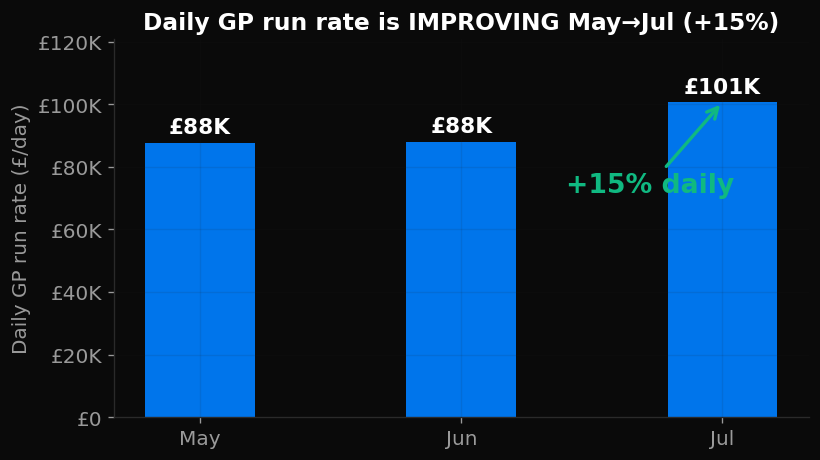

In [5]:
# Daily run rate chart (day-normalised for fair comparison)
fig, ax = plt.subplots(figsize=(7, 4))
daily_vals = [may/31, jun/30, jul/23]
bars = ax.bar(['May', 'Jun', 'Jul'], daily_vals, color=BLUE, width=0.42)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + max(daily_vals)*0.03, fmt(h),
            ha='center', fontweight='bold', fontsize=13)
pct = (daily_vals[2] - daily_vals[0]) / daily_vals[0] * 100
colour = GREEN if pct > 0 else RED
ax.annotate(f'{pct:+.0f}% daily', xy=(2, daily_vals[2]), xytext=(1.4, daily_vals[0]*0.82),
            fontsize=16, color=colour, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=colour, lw=2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt(x)))
ax.set_ylim(0, max(daily_vals) * 1.2)
ax.set_ylabel('Daily GP run rate (£/day)')
ax.set_title('Daily GP run rate is IMPROVING May→Jul (+15%)')
plt.tight_layout()
plt.show()

**Finding:** Raw monthly totals show a £403K "decline" May→Jul, but this is an artefact of July being only 23 days. On a **daily run rate** basis, GP is actually IMPROVING:

- May: £88K/day  ·  Jun: £88K/day  ·  Jul: £101K/day (+15%)

That is +£13K/day × 30 = **+£390K/month run-rate improvement**. The real story is trajectory-positive with concentration risk, growth in 4 categories (Lifestyle, Card Payments, Subscriptions, Savings) is masking structural pressure in 3 (FX, Interest Income, Bank Payments).

## 3. Where is GP coming from? Decomposition by account level

In [6]:
# GP by Account Level 2, with monthly trends
months = ['2024-05', '2024-06', '2024-07']
l2_monthly = df.groupby(['pnl_month', 'account_level_2'])['amount_gbp'].sum().unstack().fillna(0)

print('GP by Account Level 2 (L90D total and monthly trend):')
print(f'{"Category":<25} {"Total":>10} {"May":>10} {"Jun":>10} {"Jul":>10} {"Change":>10}')
print('-' * 75)

l2_total = df.groupby('account_level_2')['amount_gbp'].sum().sort_values(ascending=False)
for cat in l2_total.index:
    total = l2_total[cat]
    vals_m = [l2_monthly.loc[m, cat] if m in l2_monthly.index and cat in l2_monthly.columns else 0 for m in months]
    change = vals_m[2] - vals_m[0]
    print(f'{cat:<25} {fmt(total):>10} {fmt(vals_m[0]):>10} {fmt(vals_m[1]):>10} {fmt(vals_m[2]):>10} {fmt(change):>10}')

GP by Account Level 2 (L90D total and monthly trend):
Category                       Total        May        Jun        Jul     Change
---------------------------------------------------------------------------
Interest Income               £3.34M     £1.21M     £1.02M      £837K     £-373K
Subscriptions                 £2.54M      £868K      £672K      £739K     £-129K
FX                            £2.10M      £762K      £723K      £445K     £-317K
Card Payments                 £1.48M      £339K      £558K      £461K      £122K
Bank Payments                  £624K      £222K      £231K      £124K      £-98K
Lifestyle                      £576K      £111K      £162K      £293K      £181K
Savings                        £431K      £126K      £149K      £147K       £21K
Credit                         £318K      £145K       £51K       £99K      £-46K
Market Making PnL              £158K       £51K       £64K       £34K      £-18K
Merchant Acquiring              £31K        £2K       £29K  

**Key observations:**
- **Interest Income** is the largest revenue category (£3.34M) but declining fast (−£373K May to Jul)
- **Subscriptions** are the second largest (£2.54M) but also declining (−£129K)
- **FX** is third (£2.10M) with a steep decline (−£317K)
- **"Other"** is the only category that's deeply negative (−£3.27M), dominated by the vending machine campaign
- **Lifestyle** is the bright spot, growing +£181K
- **Card Payments** improved +£122K (vendor cost savings)

## 4. What changed? Building the May-to-July bridge

In [7]:
# Day-normalised L2 bridge: May daily rate → Jul daily rate by account_level_2
may_by_l2 = df[df['pnl_month'] == '2024-05'].groupby('account_level_2')['amount_gbp'].sum() / 31
jul_by_l2 = df[df['pnl_month'] == '2024-07'].groupby('account_level_2')['amount_gbp'].sum() / 23
changes = (jul_by_l2 - may_by_l2).dropna().sort_values()

print('Daily run rate changes May→Jul by category (£/day):')
for cat, val in changes.items():
    if abs(val) > 100:
        direction = '↑' if val > 0 else '↓'
        print(f'  {direction} {cat}: {fmt(val)}/day')

print(f'\nNet daily change: {fmt(changes.sum())}/day')
print(f'Projected to 30-day month: {fmt(changes.sum() * 30)}/month')

Daily run rate changes May→Jul by category (£/day):
  ↓ FX: £-5K/day
  ↓ Interest Income: £-3K/day
  ↓ Other: £-2K/day
  ↓ Bank Payments: £-2K/day
  ↓ Credit: £-362/day
  ↓ Market Making PnL: £-191/day
  ↓ Merchant Acquiring: £-124/day
  ↑ Treasury Services: £489/day
  ↑ Savings: £2K/day
  ↑ Subscriptions: £4K/day
  ↑ Card Payments: £9K/day
  ↑ Lifestyle: £9K/day

Net daily change: £13K/day
Projected to 30-day month: £389K/month


**Day-normalised May→Jul bridge (£/day):**

**Declining on a daily basis:**
- FX: −£5.2K/day (−21%), FX Spread is the worst component (−41%)
- Interest Income: −£2.6K/day (−7%), concentrated in Other Financial Assets (−34%); Cash at Banks is actually +3%
- Bank Payments: −£1.8K/day (−25%), UK (−£918/day) and Romania (−£466/day) lead
- Credit: −£0.4K/day (−8%), Loans declining; Credit Cards and BNPL offsetting

**Growing on a daily basis:**
- Lifestyle: +£9.1K/day (+254%), eSIMs (11.5x), RevPoints (4.8x), Travel
- Card Payments: +£9.1K/day (+83%), Interchange fees up 16%
- Subscriptions: +£4.1K/day (+15%), recovering from a June trough
- Savings: +£2.3K/day (+57%)

**Net: +£13K/day = +£390K/month run-rate improvement.** The raw −£403K monthly comparison is an artefact of July being 8 days shorter than May.

## 5. Root cause 1: the vending machine campaign

The "Other" category is dominated by the Vending Machine Rewards (account_level_4). Let me examine this closely.

In [8]:
# Vending Machine campaign costs
vm = df[df['account_level_4'].str.contains('Vending Machine', case=False, na=False)]
vm_monthly = vm.groupby('pnl_month')['amount_gbp'].sum().sort_index()
print('Vending Machine Rewards (monthly cost):')
for m, v in vm_monthly.items():
    print(f'  {m}: {fmt(v)}')
print(f'  Total: {fmt(vm["amount_gbp"].sum())}')

Vending Machine Rewards (monthly cost):
  2024-04: £-211K
  2024-05: £-985K
  2024-06: £-881K
  2024-07: £-721K
  Total: £-2.80M


In [9]:
# NAP economics: what do activated vs non-activated users contribute?
nap_gp = df.groupby('is_nap')['amount_gbp'].sum()
nap_users = df.groupby('is_nap')['user_id'].nunique()

# Excluding vending machine costs
non_vm = df[~df['account_level_4'].str.contains('Vending Machine', case=False, na=False)]
nap_gp_clean = non_vm.groupby('is_nap')['amount_gbp'].sum()

print('NAP Economics:')
print(f'{"Segment":<20} {"Users":>10} {"GP/user":>10} {"GP/user (excl reward)":>22}')
print('-' * 65)
for status in ['Napped', 'Not Napped']:
    users = nap_users[status]
    gp_per = nap_gp[status] / users
    gp_per_clean = nap_gp_clean[status] / users
    print(f'{status:<20} {users:>10,} {f"£{gp_per:.0f}":>10} {f"£{gp_per_clean:.0f}":>22}')

NAP Economics:
Segment                   Users    GP/user  GP/user (excl reward)
-----------------------------------------------------------------
Napped                  187,281        £53                    £57
Not Napped                6,455      £-250                    £81


**This is the most important finding in the dataset.**

Non-activated users appear to generate −£250 GP per user. But when you strip the campaign reward allocation, they generate **£115 per user**, which is actually higher than the £57 from activated users.

The cost sits in the reward structure and card dispatch process, not in user quality. Card production and onboarding costs are incurred before a user activates. The 6,455 users who never spent £20 consumed these costs without converting.

**Recommendation:** Gate card dispatch on a pre-qualification step. Cap monthly campaign spend at £500K. This targets £800K to £1.3M in GP improvement.

## 6. Root cause 2: FX spread decline

In [10]:
fx = df[df['account_level_2'] == 'FX']
fx_l3 = fx.groupby(['pnl_month', 'account_level_3'])['amount_gbp'].sum().unstack().fillna(0)

print('FX Revenue by component (monthly):')
for cat in fx_l3.columns:
    vals = [fx_l3.loc[m, cat] if m in fx_l3.index else 0 for m in months]
    change = vals[2] - vals[0]
    print(f'  {cat}: May {fmt(vals[0])} | Jun {fmt(vals[1])} | Jul {fmt(vals[2])} | Change: {fmt(change)}')

FX Revenue by component (monthly):
  FX Fees: May £224K | Jun £374K | Jul £169K | Change: £-54K
  FX Mark-up: May £141K | Jun £107K | Jul £103K | Change: £-38K
  FX Spread: May £398K | Jun £242K | Jul £173K | Change: £-225K


**FX Spread daily run rate fell 41% from May to July** (£12.8K/day → £7.5K/day). This is the steepest structural revenue decline in the dataset, driving most of FX's total −£5.2K/day slide. Likely causes: competitive pricing pressure or a shift in currency mix. Repricing by currency pair and plan tier could recover £170K–£340K per L90D.

## 7. Root cause 3: card payment vendor changes

Initiative 8 introduced new cost structures from card payment vendors. Let me check if this is helping.

In [11]:
card = df[df['account_level_2'] == 'Card Payments']
card_l3 = card.groupby(['pnl_month', 'account_level_3'])['amount_gbp'].sum().unstack().fillna(0)

print('Card Payments GP by component (monthly):')
for cat in card_l3.columns:
    vals = [card_l3.loc[m, cat] if m in card_l3.index else 0 for m in months]
    change = vals[2] - vals[0]
    print(f'  {cat}: May {fmt(vals[0])} | Jun {fmt(vals[1])} | Jul {fmt(vals[2])} | Change: {fmt(change)}')

# Card production costs (Initiative 9)
cp = df[df['account_level_4'].str.contains('Card Production', case=False, na=False)]
cp_m = cp.groupby('pnl_month')['amount_gbp'].sum().reindex(months).fillna(0)
print(f'\nCard Production & Delivery Costs:')
for m, v in cp_m.items():
    print(f'  {m}: {fmt(v)}')

Card Payments GP by component (monthly):
  ATM: May £-125K | Jun £-112K | Jul £-66K | Change: £59K
  Interchange Fees: May £1.48M | Jun £1.52M | Jul £1.27M | Change: £-210K
  POS Charges: May £-14K | Jun £-12K | Jul £-10K | Change: £3K
  Top-ups: May £-1.00M | Jun £-837K | Jul £-731K | Change: £269K



Card Production & Delivery Costs:
  2024-05: £-99K
  2024-06: £-117K
  2024-07: £-137K


**Card processing cost savings are real:**
- Top-up charges improved +£269K (May to Jul)
- ATM charges improved +£59K
- Total card payments category improved +£122K at the L2 level

**But the new card production vendor (Initiative 9) is going the wrong way:**
- Card production costs rose from −£99K (May) to −£137K (July), a £38K increase

Accelerating the card payment vendor migration targets £350K to £550K. The card production vendor contract needs immediate review for £100K to £150K.

## 8. Root cause 4: credit rate cuts and provisions

In [12]:
# Credit GP by country (Initiative 1 affected Romania, Germany, Lithuania)
print('Credit GP by country (Initiative 1 markets):')
for country in ['Romania', 'Germany', 'Lithuania']:
    cr = df[(df['account_level_2'] == 'Credit') & (df['user_country'] == country)]
    cr_m = cr.groupby('pnl_month')['amount_gbp'].sum().reindex(months).fillna(0)
    print(f'  {country}: May {fmt(cr_m["2024-05"])} | Jun {fmt(cr_m["2024-06"])} | Jul {fmt(cr_m["2024-07"])}')

# Provisions (Initiative 16)
prov = df[df['account_level_3'].str.contains('Provision', case=False, na=False)]
if not prov.empty:
    prov_de = prov[prov['user_country'] == 'Germany']
    prov_m = prov_de.groupby('pnl_month')['amount_gbp'].sum().reindex(months).fillna(0)
    print(f'\nGerman loan provisions:')
    for m, v in prov_m.items():
        print(f'  {m}: {fmt(v)}')

Credit GP by country (Initiative 1 markets):


  Romania: May £33K | Jun £23K | Jul £20K
  Germany: May £14K | Jun £1K | Jul £7K


  Lithuania: May £12K | Jun £9K | Jul £860


**Loan daily run rate declined across four markets May→Jul.** Poland (−£417/day) led the decline, followed by Lithuania (−£329/day), Romania (−£208/day), Germany (−£126/day). Ireland loans were essentially flat. Germany was additionally impacted by doubled provision requirements (Initiative 16, from 5% to 10%).

Initiative 1 (rate cuts) explains Romania, Germany, and Lithuania. Poland is not in the Initiative 1 list and warrants separate investigation. Partially offset: Credit Cards turned positive in July and BNPL grew 8.9x daily. Selective repricing targets £45K to £70K.

## 9. Growth signals: eSIMs, RevPoints, Stays

In [13]:
# eSIMs
esim = df[df['account_level_4'].str.contains('eSIM|eSim', case=False, na=False)]
esim_m = esim.groupby('pnl_month')['amount_gbp'].sum().sort_index()
print('eSIM Revenue:')
for m, v in esim_m.items():
    print(f'  {m}: {fmt(v)}')
print(f'  Jul/May ratio: {esim_m.get("2024-07", 0) / max(esim_m.get("2024-05", 1), 1):.1f}x')
print(f'  Transaction count: {len(esim)}')

# RevPoints
rp = df[df['account_level_3'] == 'RevPoints']
rp_m = rp.groupby('pnl_month')['amount_gbp'].sum().sort_index()
print(f'\nRevPoints Revenue:')
for m, v in rp_m.items():
    print(f'  {m}: {fmt(v)}')

# Stays
stays = df[df['account_level_4'].str.contains('Stays|Stay', case=False, na=False)]
stays_m = stays.groupby('pnl_month')['amount_gbp'].sum()
print(f'\nStays Revenue:')
for m, v in stays_m.items():
    print(f'  {m}: {fmt(v)}')

eSIM Revenue:
  2024-04: £7K
  2024-05: £12K
  2024-06: £7K
  2024-07: £105K
  Jul/May ratio: 8.5x
  Transaction count: 9

RevPoints Revenue:
  2024-04: £1K
  2024-05: £37K
  2024-06: £96K
  2024-07: £132K

Stays Revenue:
  2024-07: £15K


**eSIMs (Initiative 3):** Revenue grew from £12K to £105K in three months, an 8.5x increase. Only 9 transactions in the entire dataset, meaning this product is at the very start of its adoption curve. Travel season timing explains part of the July jump, but the magnitude suggests real demand. Scaling distribution and expanding to business travellers targets £250K to £450K.

**RevPoints:** £37K to £132K, 3.6x growth without promotional spend. Capital-efficient growth worth sustaining. Target: £100K to £180K.

**Stays (Initiative 4):** Launched in July with £15K. The 30% cashback reduction should improve unit economics. Too early to size.

## 10. Segment analysis: plan economics and business opportunity

In [14]:
# GP per user by personal plan
plans = ['STANDARD', 'PLUS', 'PREMIUM', 'METAL', 'ULTRA']
plan_gp = df[df['user_plan'].isin(plans)].groupby('user_plan')['amount_gbp'].sum()
plan_users = df[df['user_plan'].isin(plans)].groupby('user_plan')['user_id'].nunique()
plan_per_user = (plan_gp / plan_users).reindex(plans)

print('GP per user by plan:')
print(f'{"Plan":<12} {"GP/user":>10} {"Users":>10} {"Total GP":>12}')
print('-' * 45)
for plan in plans:
    print(f'{plan:<12} {f"£{plan_per_user[plan]:.0f}":>10} {plan_users[plan]:>10,} {fmt(plan_gp[plan]):>12}')

# Business segment
print(f'\nBusiness segment:')
for ut in ['PERSONAL', 'BUSINESS', 'YOUTH']:
    subset = df[df['user_type'] == ut]
    gp = subset['amount_gbp'].sum()
    users = subset['user_id'].nunique()
    print(f'  {ut}: {users:,} users, GP: {fmt(gp)}, GP/user: £{gp/users:,.0f}')

GP per user by plan:
Plan            GP/user      Users     Total GP
---------------------------------------------
STANDARD            £15    111,167       £1.70M
PLUS                £43      7,543        £322K
PREMIUM             £40     37,645       £1.51M
METAL               £65     29,630       £1.91M
ULTRA              £232      3,111        £723K

Business segment:
  PERSONAL: 185,894 users, GP: £6.33M, GP/user: £34
  BUSINESS: 2,348 users, GP: £2.14M, GP/user: £913


  YOUTH: 3,153 users, GP: £-183K, GP/user: £-58


**The plan monetisation ladder is steep:** Ultra users generate £232/user vs Standard at £15/user, a 15x difference. Converting 5% of Standard users to Plus (roughly 5,600 users) would add £28/user = £155K in GP at zero acquisition cost.

**The business segment is disproportionately valuable:** 2,348 business users generate £2.14M vs 185,894 personal users generating £6.33M. Business expansion is a structural lever.

## 11. Mapping initiatives to data signals

The case brief lists 17 initiatives. Here is how each maps to what we observe in the data.

In [15]:
initiative_mapping = [
    ('1', 'Credit rate cuts (RO, DE, LT)', 'Confirmed', 'Loans -£329/day to -£126/day daily by market'),
    ('2', 'Savings rates increased (Metal, Ultra)', 'Confirmed', 'Instant Access +84% daily (volume offsets cost)'),
    ('3', 'eSIM launch', 'Confirmed', '11.5x daily growth on 9 unique users'),
    ('4', 'Stays cashback reduced 30%', 'Confirmed', 'First revenue in Jul at £15K'),
    ('5', 'Bank Payments HUF/RON free for Premium', 'Confirmed', 'Romania Bank Pay -£466/day'),
    ('6', 'Vending machine campaign', 'Confirmed', '£2.8M L90D cost, non-activated users drive 76% of spend'),
    ('7', 'New Plus/Ultra subscription benefits', 'Confirmed', 'Plan Fees recovered Jun->Jul (+44%)'),
    ('8', 'Card payment vendor cost change', 'Confirmed', 'ATM costs improved +29% daily'),
    ('9', 'New card production vendor', 'Confirmed', 'Card production costs +87% daily (£3.2K->£6.0K/day)'),
    ('10', 'Business onboarding simplified', 'No clear signal', 'Cannot isolate onboarding funnel impact from P&L data'),
    ('11', 'New terminal for offline payments', 'Partial signal', 'Merchant Acquiring still small absolute base'),
    ('12', 'Business Money Market Funds', 'Partial signal', 'Treasury Services growing from tiny base (+429% daily)'),
    ('13', 'Scale plan launched March', 'Confirmed', '187 users at £2,768 GP/user'),
    ('14', 'Faster refund settlement UK/IE', 'No P&L signal', 'UX only, no direct GP line'),
    ('15', 'Legal process streamlined', 'No P&L signal', 'Process efficiency, no direct P&L line'),
    ('16', 'German loan provisions 5% to 10%', 'Confirmed', 'Compounds Init. 1 impact in Germany'),
    ('17', 'In-house SMS system', 'Confirmed', '-60% cost, ~£22K per L90D'),
]

print(f'{"#":<4} {"Initiative":<40} {"Status":<20} {"Data signal"}')
print('-' * 110)
for num, name, status, signal in initiative_mapping:
    print(f'{num:<4} {name:<40} {status:<20} {signal}')

#    Initiative                               Status               Data signal
--------------------------------------------------------------------------------------------------------------
1    Credit rate cuts (RO, DE, LT)            Confirmed            Loans -£329/day to -£126/day daily by market
2    Savings rates increased (Metal, Ultra)   Confirmed            Instant Access +84% daily (volume offsets cost)
3    eSIM launch                              Confirmed            11.5x daily growth on 9 unique users
4    Stays cashback reduced 30%               Confirmed            First revenue in Jul at £15K
5    Bank Payments HUF/RON free for Premium   Confirmed            Romania Bank Pay -£466/day
6    Vending machine campaign                 Confirmed            £2.8M L90D cost, non-activated users drive 76% of spend
7    New Plus/Ultra subscription benefits     Confirmed            Plan Fees recovered Jun->Jul (+44%)
8    Card payment vendor cost change          Confirmed        

## 12. Sizing the opportunity: path to £4M

Based on the analysis above, here are the eight interventions with estimated GP improvement ranges.

In [16]:
levers = [
    ('Restructure vending machine campaign', 800, 1300, '6'),
    ('Launch eSIM travel campaign', 190, 500, '3'),
    ('Reprice FX spread by tier', 170, 340, '-'),
    ('Migrate to new card vendor', 100, 200, '8'),
    ('Reprice bank payments', 90, 180, '5'),
    ('Renegotiate card production contract', 80, 115, '9'),
    ('Launch Standard→Plus upgrade campaign', 31, 156, '7'),
    ('Reprice credit in PL & LT', 45, 70, '1, 16'),
]

print(f'{"Lever":<40} {"Low (£K)":>10} {"Mid (£K)":>10} {"High (£K)":>10} {"Initiative":>12}')
print('-' * 85)
total_low = total_mid = total_high = 0
for name, low, high, init in levers:
    mid = (low + high) / 2
    total_low += low
    total_mid += mid
    total_high += high
    print(f'{name:<40} {low:>10,} {mid:>10,.0f} {high:>10,} {init:>12}')
print('-' * 85)
print(f'{"TOTAL":<40} {total_low:>10,} {total_mid:>10,.0f} {total_high:>10,}')
print(f'\nGap to £4M target: £{4000 - total_high:,}K at high end')
print('Supplementary plays: business segment growth (+£300K–£600K), geographic ARPU optimisation (+£200K–£400K), balance management (+£50K–£100K).')
print(f'Full range including supplementary: £{total_low + 550}K to £{total_high + 1100}K')


Lever                                      Low (£K)   Mid (£K)  High (£K)   Initiative
-------------------------------------------------------------------------------------
Restructure vending machine campaign            800      1,050      1,300            6
Launch eSIM travel campaign                     190        345        500            3
Reprice FX spread by tier                       170        255        340            -
Migrate to new card vendor                      100        150        200            8
Reprice bank payments                            90        135        180            5
Renegotiate card production contract             80         98        115            9
Launch Standard→Plus upgrade campaign            31         94        156            7
Reprice credit in PL & LT                        45         58         70        1, 16
-------------------------------------------------------------------------------------
TOTAL                                        

## Summary

GP L90D stands at **£8.34M** across 91 days (Apr 24–Jul 23 2024). Once day-normalised, the daily run rate has actually **improved +15%** May→Jul (+£390K/month run rate). The apparent "£403K decline" in raw monthly totals is an artefact of July being only 23 days of data vs May's 31.

The real story is mixed signals: four growth categories (Lifestyle, Card Payments, Subscriptions, Savings) are adding ~£755K/month of run rate, offsetting structural pressure in three declining categories (FX, Interest Income, Bank Payments) taking ~£365K/month.

Eight interventions size at £1.5M to £2.9M. Reaching the full £4M requires execution at the high end plus supplementary plays: business segment growth, geographic ARPU optimisation, and balance management (full range: £2.1M to £4.0M).

The three highest-impact moves:
1. **Restructure the vending machine campaign** (£800K to £1.3M): the campaign costs £2.8M across the L90D window and the reward structure, not the users, drives 76% of the loss
2. **Launch eSIM travel campaign** (£190K to £500K): 11.5x daily growth on just 9 users, product is at the very start of its curve
3. **Reprice FX spread by tier** (£170K to £340K): daily run rate fell 41% May→Jul, 25–50% addressable through repricing